##Imports


In [6]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
#Load Dataset

df = pd.read_csv("customer_support_text_classification.csv")

print(df.head())

  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  


##Task 1: Dataset Understanding

In [8]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nClass Labels:")
print(df['sentiment_label'].unique())

print("\nClass Distribution:")
print(df['sentiment_label'].value_counts())

Dataset Shape:
(1500, 6)

Columns:
Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')

Class Labels:
['neutral' 'positive' 'negative']

Class Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


In [9]:
#Sample Records

print("\nSample Messages:\n")

for i in range(5):
    print(df['customer_message'][i])
    print()


Sample Messages:

I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

I need information about the payment process.

The refund process was fast and convenient. I appreciate the quick response.

My refund is still pending and this experience is frustrating. My ticket number is 33927.

Please tell me how to update my account details.



In [10]:
#Average Text Length

df['text_length'] = df['customer_message'].astype(str).apply(len)

print("Average Text Length:")
print(df['text_length'].mean())

Average Text Length:
72.75666666666666


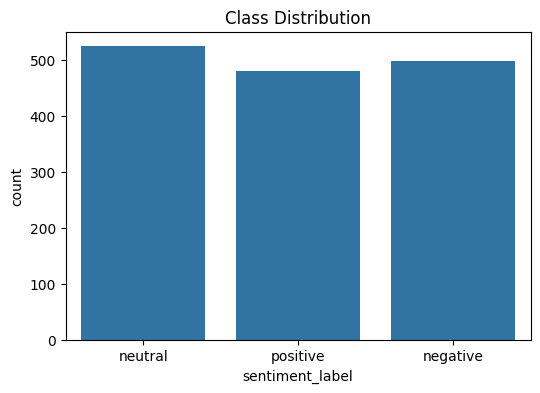

In [11]:
#Visualize Class Distribution

plt.figure(figsize=(6,4))
sns.countplot(x='sentiment_label', data=df)
plt.title("Class Distribution")
plt.show()

##Task 2: Text Preprocessing

In [ ]:
#Define Stopwords

stop_words = set(stopwords.words('english'))

In [ ]:
#Cleaning Function

def clean_text(text):

    text = str(text).lower()

    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # tokenize
    tokens = word_tokenize(text)

    # remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

In [ ]:
#Apply Cleaning

df['cleaned_text'] = df['customer_message'].apply(clean_text)

print(df[['customer_message', 'cleaned_text']].head())

##Task 3: Text Vectorization

Why Text Must Be Converted into Vectors -->

Machine learning models process numbers, not raw text.

Text vectorization converts words into numerical representations so models can: Detect patterns, Calculate similarities, Learn relationships

Examples: Bag of Words, TF-IDF, Word Embeddings, Token Sequences

In [18]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Define Stopwords (if not already defined)
stop_words = set(stopwords.words('english'))

# Define Cleaning Function (if not already defined)
def clean_text(text):
    text = str(text).lower()
    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # tokenize
    tokens = word_tokenize(text)
    # remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['cleaned_text'] = df['customer_message'].apply(clean_text)

In [19]:
#TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['cleaned_text']).toarray()
y = df['sentiment_label']

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
#Train Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

#Evaluate Model
y_pred = log_reg.predict(X_test)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Logistic Regression Accuracy: 1.0


##Task 4: Baseline Model

In [21]:
#Logistic Regression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [22]:
#Evaluation

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [ ]:
#Confusion Matrix

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
#Save Evaluation

report = classification_report(y_test, predictions, output_dict=True)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv("results/model_evaluation.csv")

In [ ]:
#Sample Predictions File

sample_df = pd.DataFrame({
    "Text": df['customer_message'].iloc[:10],
    "Actual": y.iloc[:10],
    "Predicted": model.predict(X[:10])
})

sample_df.to_csv("results/sample_predictions.txt", index=False)

#Task 5: Sequence Model (LSTM)

Traditional TF-IDF ignores word order.

Example:"not good" "good"

TF-IDF may treat them similarly.

Sequence models preserve order.

In [ ]:
#Tokenization

MAX_WORDS = 5000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS)

tokenizer.fit_on_texts(df['cleaned_text'])

sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

In [ ]:
#Padding Sequences

X_seq = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

In [ ]:
#Encode Labels

label_mapping = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

y_seq = df['sentiment_label'].map(label_mapping)

In [ ]:
#Split Data

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Build LSTM Model

lstm_model = Sequential([

    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),

    LSTM(64),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
])

In [ ]:
#Compile Model

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Train Model

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

In [ ]:
#Evaluate

loss, accuracy = lstm_model.evaluate(X_test_seq, y_test_seq)

print("LSTM Accuracy:", accuracy)

Input Sequence-->

Example sentence: "The service was very slow"
Converted into: [12, 45, 8, 91, 300]

---
Embedding Layer-->

Maps words into dense vectors.
Words with similar meanings become closer in vector space.

---
LSTM Layer

Processes words sequentially while maintaining memory.

Learns: context, dependencies, sentiment flow

---
Output Layer

Uses softmax activation to predict: positive, neutral, negative

---
Loss Function

Sparse Categorical Crossentropy : Used for multi-class classification.


---
Evaluation Metric

Accuracy : Measures percentage of correct predictions.

#Task 6: Attention and Transformer Reflection

Why RNNs Struggle with Long-Term Dependencies-->

RNNs process sequences step-by-step.

As sequences become longer: earlier information fades, gradients vanish, important context gets lost

This makes learning long-range relationships difficult.


---


How LSTMs Help -->

LSTMs introduce: memory cells, input gates, forget gates, output gates

These mechanisms help preserve important information over longer sequences.


---


What Attention Solves -->

Attention allows models to: focus on relevant words directly, avoid compressing everything into one hidden state

Example: In translation: the model can attend to important source words while generating output.

Attention improves: context understanding, long-sequence handling, translation quality


---


Why Transformers Are Important

Transformers: use self-attention, process sequences in parallel, scale efficiently on massive datasets

Advantages: faster training, better context understanding, superior long-range dependency learning

Modern NLP systems like: OpenAI GPT, Google BERT, T5, LLaMA are transformer-based architectures.

#Results

In [24]:
import os

# Create 'results' directory if it doesn't exist
if not os.path.exists('results'):
    os.makedirs('results')

# Save Evaluation to CSV
report = classification_report(y_test, predictions, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv("results/model_evaluation.csv")
print("model_evaluation.csv saved to results/model_evaluation.csv")

# Save Sample Predictions to TXT
sample_df = pd.DataFrame({
    "Text": df['customer_message'].iloc[:10],
    "Actual": y.iloc[:10],
    "Predicted": model.predict(X[:10])
})
sample_df.to_csv("results/sample_predictions.txt", index=False)
print("sample_predictions.txt saved to results/sample_predictions.txt")

model_evaluation.csv saved to results/model_evaluation.csv
sample_predictions.txt saved to results/sample_predictions.txt
